In [9]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import albumentations as A
import segmentation_models_pytorch as smp

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TRAIN_ROOT = "./LoveDA_patch/Train"
VAL_ROOT   = "./LoveDA_patch/Val"
TEST_ROOT  = "./Test/Test"

IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 100

NUM_CLASSES = 8
LR_G = 1e-4
LR_D = LR_G/4
LAMBDA_ADV = 0.01

In [11]:
class PatchDataset(Dataset):

    def __init__(self, root):

        self.img_dir = os.path.join(root,"images")
        self.mask_dir = os.path.join(root,"masks")

        self.images = os.listdir(self.img_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        name = self.images[idx]

        img_path = os.path.join(self.img_dir,name)
        mask_path = os.path.join(self.mask_dir,name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path,0)

        image = image.astype("float32")/255.0

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).long()

        return image,mask

In [12]:
class LoveDATestDataset(Dataset):

    def __init__(self, root):

        self.images = []

        for area in ["Rural","Urban"]:

            img_dir = os.path.join(root, area, "images_png")

            for img in os.listdir(img_dir):

                self.images.append(os.path.join(img_dir,img))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        path = self.images[idx]

        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        return image, path

In [13]:
train_dataset = PatchDataset(TRAIN_ROOT)
val_dataset = PatchDataset(VAL_ROOT)
test_dataset = LoveDATestDataset(TEST_ROOT)

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=4)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE)

test_loader = DataLoader(test_dataset,batch_size=1)

In [14]:
class UNetDown(nn.Module):
    def __init__(self, in_size, out_size, normalize=True, dropout=0.0):
        super(UNetDown, self).__init__()
        layers = [nn.Conv2d(in_size, out_size, kernel_size=4, stride=2, padding=1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_size))
        layers.append(nn.LeakyReLU(0.2))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_size, out_size, dropout=0.0):
        super(UNetUp, self).__init__()
        layers = [
            nn.ConvTranspose2d(in_size, out_size, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_size),
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x

class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=NUM_CLASSES):
        super(Generator, self).__init__()
        
        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)
        self.down7 = UNetDown(512, 512, dropout=0.5)
        self.down8 = UNetDown(512, 512, normalize=False, dropout=0.5)

        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 512, dropout=0.5)
        self.up4 = UNetUp(1024, 512, dropout=0.5)
        self.up5 = UNetUp(1024, 256)
        self.up6 = UNetUp(512, 128)
        self.up7 = UNetUp(256, 64)

        # Lớp cuối KHÔNG có activation để khớp với nn.CrossEntropyLoss
        self.final = nn.ConvTranspose2d(128, out_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)

        u1 = self.up1(d8, d7)
        u2 = self.up2(u1, d6)
        u3 = self.up3(u2, d5)
        u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3)
        u6 = self.up6(u5, d2)
        u7 = self.up7(u6, d1)

        return self.final(u7)

In [15]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        in_channels = 3 + NUM_CLASSES

        self.net = nn.Sequential(
            # Khối 1
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Khối 2
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Khối 3
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Khối 4 (Stride = 1 thay vì 2 để giữ nguyên kích thước Patch)
            nn.Conv2d(256, 512, kernel_size=4, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Khối Output
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)
        )

    def forward(self, image, mask):
        x = torch.cat([image, mask], dim=1)
        return self.net(x)

In [ ]:
G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

opt_G = torch.optim.Adam(G.parameters(),lr=LR_G)
opt_D = torch.optim.Adam(D.parameters(),lr=LR_D)

bce = nn.BCEWithLogitsLoss()
weights = torch.tensor([
1.0,   # background
2.0,   # building
2.0,   # road
2.0,   # water
1.0,   # barren
1.5,   # forest
0.5,   # agriculture
1.0    # unknown
]).to(DEVICE)

ce = nn.CrossEntropyLoss(weight=weights)
ce = nn.CrossEntropyLoss(weight=weights)

In [17]:
for epoch in range(EPOCHS):

    G.train()

    for images,masks in tqdm(train_loader):

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        onehot = F.one_hot(masks,NUM_CLASSES).permute(0,3,1,2).float()

        fake_logits = G(images)
        fake_masks = torch.softmax(fake_logits,1)

        # train discriminator
        opt_D.zero_grad()

        real_out = D(images,onehot)
        fake_out = D(images,fake_masks.detach())

        loss_real = bce(real_out,torch.ones_like(real_out))
        loss_fake = bce(fake_out,torch.zeros_like(fake_out))

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # train generator
        opt_G.zero_grad()

        pred = D(images,fake_masks)

        adv_loss = bce(pred,torch.ones_like(pred))
        seg_loss = ce(fake_logits,masks)

        loss_G = seg_loss + LAMBDA_ADV*adv_loss

        loss_G.backward()
        opt_G.step()

    print("Epoch",epoch,"Loss G",loss_G.item(),"Loss D",loss_D.item())

100%|██████████| 5044/5044 [18:48<00:00,  4.47it/s]


Epoch 0 Loss G 0.9799196124076843 Loss D 0.00035798491444438696


100%|██████████| 5044/5044 [18:50<00:00,  4.46it/s]


Epoch 1 Loss G 1.1861374378204346 Loss D 3.203391679562628e-05


100%|██████████| 5044/5044 [19:03<00:00,  4.41it/s]


...

Epoch 97 Loss G 0.6024045348167419 Loss D 9.49356490309583e-07


100%|██████████| 5044/5044 [17:53<00:00,  4.70it/s]


Epoch 98 Loss G 0.48244380950927734 Loss D 3.610103078699467e-07


100%|██████████| 5044/5044 [17:40<00:00,  4.75it/s]


Epoch 99 Loss G 0.4936249852180481 Loss D 1.6520903756145344e-08


In [18]:
def segment_large_image(model, image, device="cuda", patch_size=256):

    h, w, _ = image.shape

    output_mask = np.zeros((h,w), dtype=np.uint8)

    model.eval()

    with torch.no_grad():

        for y in range(0, h, patch_size):
            for x in range(0, w, patch_size):

                patch = image[y:y+patch_size, x:x+patch_size]

                if patch.shape[0] != patch_size or patch.shape[1] != patch_size:
                    continue

                patch = patch.astype("float32")/255.0
                patch = torch.tensor(patch).permute(2,0,1).unsqueeze(0).to(device)

                pred = model(patch)

                pred = torch.argmax(pred,1).cpu().numpy()[0]

                output_mask[y:y+patch_size, x:x+patch_size] = pred

    return output_mask

In [22]:
G.eval()

os.makedirs("predictions",exist_ok=True)

for image,path in test_loader:

    image = image[0].numpy()

    pred_mask = segment_large_image(G,image,DEVICE)

    name = os.path.basename(path[0])

    cv2.imwrite("predictions/"+name,pred_mask)

In [23]:
LOVE_DA_COLORS = np.array([
    [0,0,0],        # background
    [255,0,0],      # building
    [255,255,0],    # road
    [0,0,255],      # water
    [159,129,183],  # barren
    [0,255,0],      # forest
    [255,195,128],  # agriculture
    [128,128,128]   # unknown
])

CLASS_NAMES = [
    "background",
    "building",
    "road",
    "water",
    "barren",
    "forest",
    "agriculture",
    "unknown"
]

In [24]:
def decode_segmap(mask):

    color_mask = LOVE_DA_COLORS[mask]

    return color_mask.astype(np.uint8)

In [25]:
def overlay(image, mask):

    color_mask = decode_segmap(mask)

    overlay = image * 0.6 + color_mask * 0.4

    return overlay.astype(np.uint8)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

def visualize_prediction(model, dataset):

    idx = random.randint(0,len(dataset)-1)

    image, path = dataset[idx]

    pred_mask = segment_large_image(model,image,DEVICE)

    color_mask = decode_segmap(pred_mask)

    overlay_img = overlay(image,pred_mask)

    plt.figure(figsize=(18,6))

    # Image
    plt.subplot(1,3,1)
    plt.title("Test Image")
    plt.imshow(image)
    plt.axis("off")

    # Mask
    plt.subplot(1,3,2)
    plt.title("Predicted Mask")
    plt.imshow(color_mask)
    plt.axis("off")

    # Overlay
    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(overlay_img)
    plt.axis("off")

    # Legend
    patches = [
        mpatches.Patch(color=np.array(c)/255, label=l)
        for c,l in zip(LOVE_DA_COLORS,CLASS_NAMES)
    ]

    plt.legend(
        handles=patches,
        bbox_to_anchor=(1.05,1),
        loc="upper left"
    )

    plt.show()

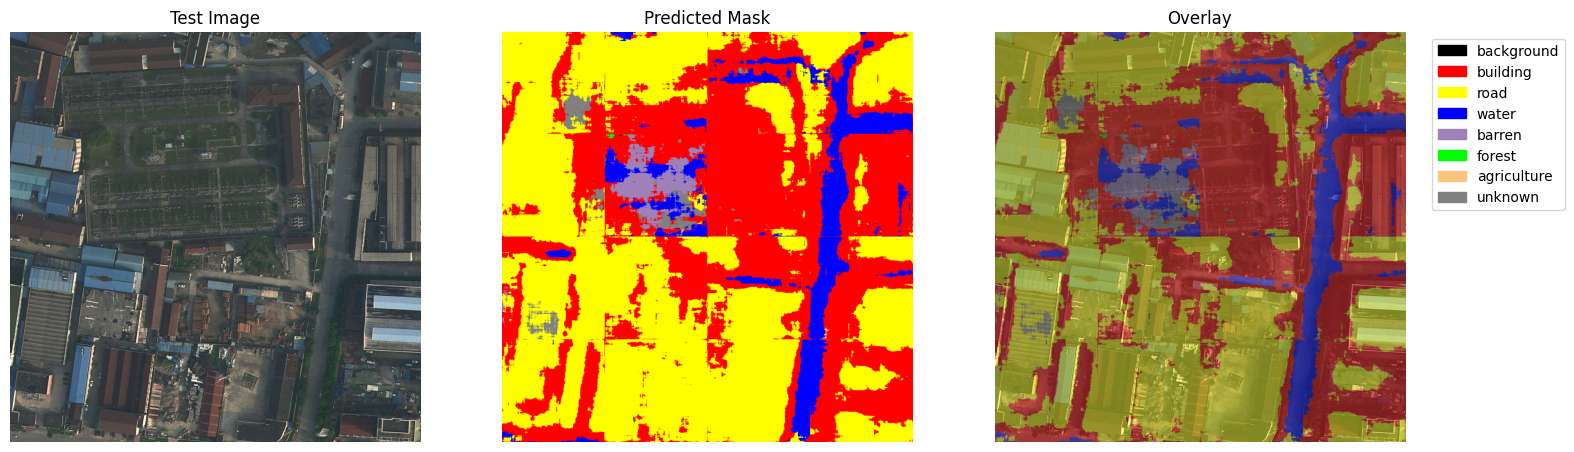

In [27]:
visualize_prediction(G, test_dataset)